# 01 — Capture → 2D pose → 3D lift

First-stage debug notebook. Records a 20-second clip, then runs it through the first three pipeline modules in isolation:

1. **`workout_ai.capture`** — sanity-check the webcam, then record `data/clip.mp4`.
2. **`workout_ai.pose2d`** — replay the clip through RTMPose, save an annotated mp4 and the per-frame keypoint array.
3. **`workout_ai.pose3d`** — auto-pick the deepest-squat moment from the recording, lift its 27-frame window with MotionBERT-Lite, plot the (17,3) H36M rig.

Recording-first (not live preview) because ipywidgets buttons are unreliable inside long Python loops, and a saved clip is reproducible across code changes. Heavy models (`Pose2D`, `Pose3D`) are loaded once and reused across cell re-runs.


## Setup


In [1]:
import sys, time
from pathlib import Path

# Locate project root whether the notebook is launched from ./ or ./notebooks/
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  # registers 3d projection
import ipywidgets as widgets
from IPython.display import display
import torch

print("project root:", PROJECT_ROOT)
print("MPS available:", torch.backends.mps.is_available())

project root: /Users/thatt/Dev/AI project/new-workout-ai
MPS available: True


In [2]:
# Slow on first run (rtmlib downloads / weights load). Re-running this cell is a no-op
# while the kernel is alive — `pose` and `lifter` are reused.
from workout_ai.pose2d import Pose2D
from workout_ai.pose3d import Pose3D, coco17_to_h36m17
from workout_ai.render import Renderer
from workout_ai.capture import WebcamCapture

if "pose" not in globals():
    pose = Pose2D()
    print("Pose2D ready")
else:
    print("Pose2D already loaded — skipping")

if "lifter" not in globals():
    lifter = Pose3D()
    print("Pose3D ready on", lifter.device)
else:
    print("Pose3D already loaded — skipping")

renderer = Renderer()

load /Users/thatt/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /Users/thatt/.cache/rtmlib/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend
Pose2D ready
Pose3D ready on mps


## Stage 1 — Capture sanity check

Open the webcam, pull one frame, confirm it's a `(720, 1280, 3)` `uint8` BGR array, and display it. If this cell fails, nothing downstream will work.


shape: (720, 1280, 3) dtype: uint8 mean brightness: 14.606801215277779


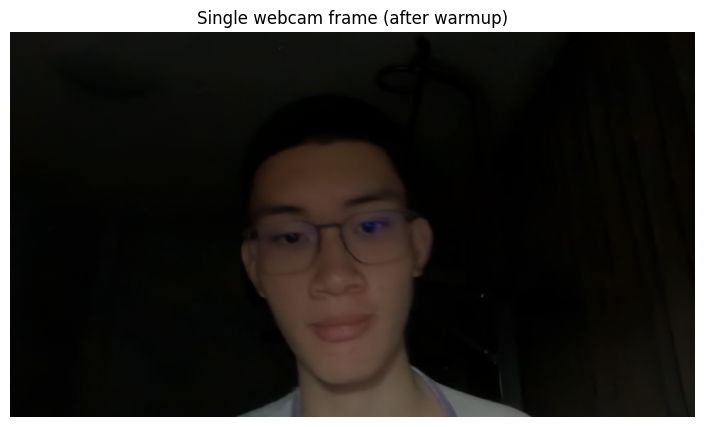

In [ ]:
# Quick camera check. macOS often returns a pitch-black first frame before
# auto-exposure settles, so discard ~15 warmup frames before keeping one.
cam = cv2.VideoCapture(0)
cam.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cam.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
for _ in range(15):
    cam.read()
ok, frame = cam.read()
cam.release()

assert ok and frame is not None, (
    "no frame received — is the webcam in use by another app?"
)
print(
    "shape:",
    frame.shape,
    "dtype:",
    frame.dtype,
    "mean brightness:",
    float(frame.mean()),
)

plt.figure(figsize=(9, 5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Single webcam frame (after warmup)")
plt.show()

## Stage 1b — Record a 20-second clip

Records the webcam to `notebooks/data/clip.mp4`. **The cell blocks for 20 seconds — perform 2–3 slow squats during the recording.** Re-run the cell to overwrite the file.


In [ ]:
DATA = PROJECT_ROOT / "notebooks" / "data"
DATA.mkdir(parents=True, exist_ok=True)
CLIP = DATA / "clip.mp4"

DURATION = 20.0
W, H = 1280, 720
TARGET_FPS = 30.0

print(f"opening webcam ({W}x{H}) — recording {DURATION:.0f}s to {CLIP.name}")
print("stand back, then perform 2-3 slow squats.")

cam = cv2.VideoCapture(0)
cam.set(cv2.CAP_PROP_FRAME_WIDTH, W)
cam.set(cv2.CAP_PROP_FRAME_HEIGHT, H)
for _ in range(15):  # warmup
    cam.read()

writer = cv2.VideoWriter(str(CLIP), cv2.VideoWriter_fourcc(*"mp4v"), TARGET_FPS, (W, H))

t0 = time.monotonic()
n = 0
while time.monotonic() - t0 < DURATION:
    ok, frame = cam.read()
    if not ok:
        break
    writer.write(frame)
    n += 1
cam.release()
writer.release()
elapsed = time.monotonic() - t0
print(f"saved {n} frames in {elapsed:.1f}s ({n / elapsed:.1f} FPS) → {CLIP}")

opening webcam (1280x720) — recording 20s to clip.mp4
stand back, then perform 2-3 slow squats.
saved 357 frames in 20.1s (17.8 FPS) → /Users/thatt/Dev/AI project/new-workout-ai/notebooks/data/clip.mp4


## Stage 2 — Process the clip with 2D keypoint overlay

Read every frame of `clip.mp4`, run `Pose2D.infer`, and write two artefacts:

- `data/clip_annotated.mp4` — annotated video for external playback (open it in QuickTime / VS Code).
- `data/clip_keypoints.npy` (shape `(N, 17, 2)`) and `data/clip_scores.npy` (shape `(N, 17)`) — the raw RTMPose outputs cached for Stage 3.

Below the print log, a 3×3 grid of sample annotated frames is rendered inline as a sanity check.


reading clip.mp4: 357 frames, 1280x720 @ 30.0 fps
  60/357 frames
  120/357 frames
  180/357 frames
  240/357 frames
  300/357 frames
done: 357 frames in 8.6s (41.6 FPS)
  annotated clip  → /Users/thatt/Dev/AI project/new-workout-ai/notebooks/data/clip_annotated.mp4
  keypoints (357, 17, 2) → clip_keypoints.npy
  scores    (357, 17) → clip_scores.npy


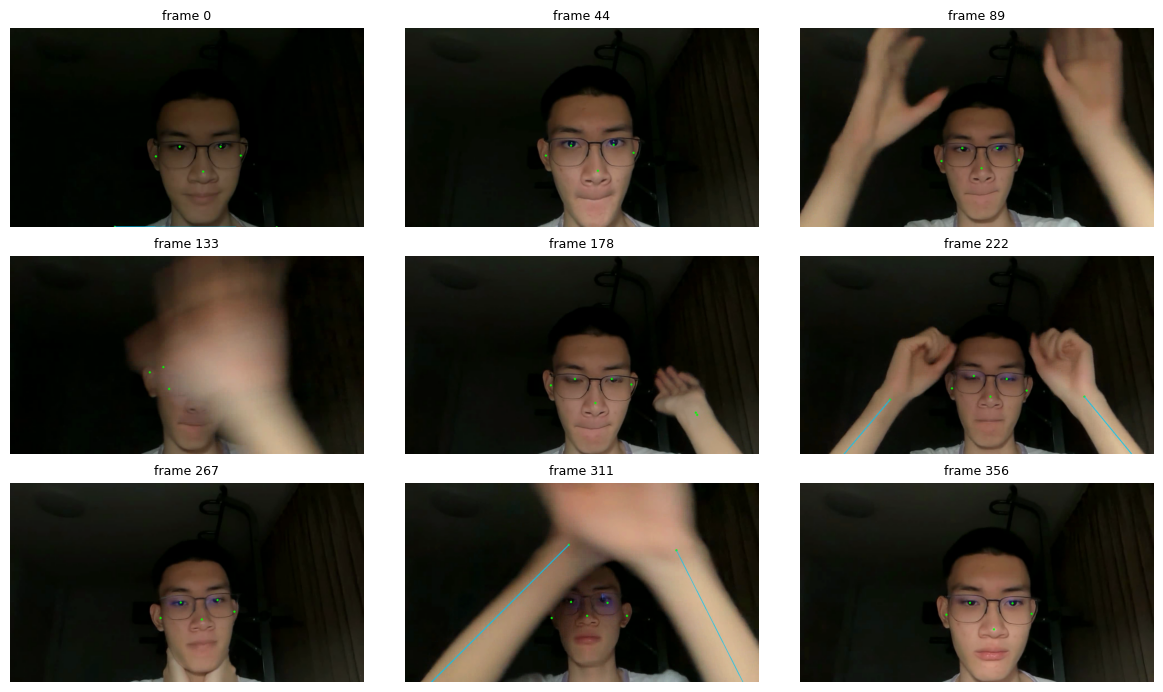

In [ ]:
CLIP_ANNOT = DATA / "clip_annotated.mp4"
KPS_NPY = DATA / "clip_keypoints.npy"
SCORES_NPY = DATA / "clip_scores.npy"

reader = cv2.VideoCapture(str(CLIP))
total = int(reader.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(reader.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_in = reader.get(cv2.CAP_PROP_FPS) or 30.0
print(f"reading {CLIP.name}: {total} frames, {W}x{H} @ {fps_in:.1f} fps")

writer = cv2.VideoWriter(
    str(CLIP_ANNOT), cv2.VideoWriter_fourcc(*"mp4v"), fps_in, (W, H)
)

all_kps, all_scores = [], []
t0 = time.monotonic()
i = 0
while True:
    ok, frame = reader.read()
    if not ok:
        break
    kps, scores = pose.infer(frame)
    all_kps.append(kps)
    all_scores.append(scores)
    drawn = renderer.draw_skeleton(frame, kps, scores)
    writer.write(drawn)
    i += 1
    if i % 60 == 0:
        print(f"  {i}/{total} frames")
reader.release()
writer.release()
dt = time.monotonic() - t0

kps_arr = np.stack(all_kps, axis=0).astype(np.float32)
scores_arr = np.stack(all_scores, axis=0).astype(np.float32)
np.save(KPS_NPY, kps_arr)
np.save(SCORES_NPY, scores_arr)
print(f"done: {i} frames in {dt:.1f}s ({i / dt:.1f} FPS)")
print(f"  annotated clip  → {CLIP_ANNOT}")
print(f"  keypoints {kps_arr.shape} → {KPS_NPY.name}")
print(f"  scores    {scores_arr.shape} → {SCORES_NPY.name}")

# Inline sanity check: 3x3 grid sampled across the annotated clip.
grid_reader = cv2.VideoCapture(str(CLIP_ANNOT))
sample_idxs = np.linspace(0, max(i - 1, 0), 9).astype(int)
fig, axes = plt.subplots(3, 3, figsize=(12, 7))
for ax, idx in zip(axes.flat, sample_idxs):
    grid_reader.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame = grid_reader.read()
    if not ok:
        ax.axis("off")
        continue
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}", fontsize=9)
    ax.axis("off")
grid_reader.release()
plt.tight_layout()
plt.show()

## Stage 3a — Auto-pick the 27-frame window

MotionBERT-Lite expects a 27-frame sliding window. We pick the window centered on the **deepest squat moment** — the frame with the smallest average left/right knee angle — from the per-frame keypoints saved above. The knee-angle curve is plotted so you can sanity-check the pick (the selected window appears as the orange band).

Saved to `data/squat_window_27.npy` (shape `(27, 17, 3)`, H36M-17 with x/y/score) so the lift cell is reproducible across kernel restarts.


clip has 357 frames
deepest squat: frame 330 (knee angle 1.5°)
selected window: frames 317..343
saved (27, 17, 3) to squat_window_27.npy


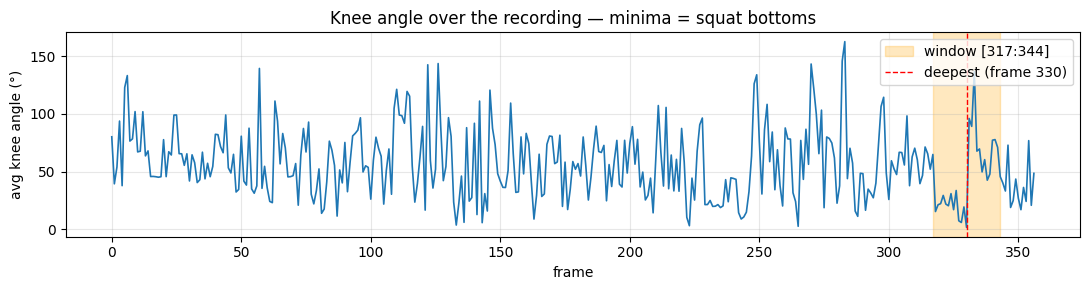

In [ ]:
from workout_ai.analysis.angles import knee_angles

kps_arr = np.load(KPS_NPY)
scores_arr = np.load(SCORES_NPY)
N = kps_arr.shape[0]
print(f"clip has {N} frames")

# Average knee angle per frame; argmin is the deepest squat moment.
angles = np.zeros(N, dtype=np.float32)
for k in range(N):
    l, r = knee_angles(kps_arr[k])
    angles[k] = (l + r) / 2.0

WIN = 27
deepest = int(np.argmin(angles))
start = max(0, deepest - WIN // 2)
end = start + WIN
if end > N:
    end = N
    start = end - WIN

print(f"deepest squat: frame {deepest} (knee angle {angles[deepest]:.1f}°)")
print(f"selected window: frames {start}..{end - 1}")
if angles[deepest] > 140.0:
    print(
        "WARNING: no deep squat detected (min knee angle > 140°). Re-record if needed."
    )

window_2d = kps_arr[start:end]
window_scores = scores_arr[start:end]
window_h36m = np.stack(
    [coco17_to_h36m17(window_2d[k], window_scores[k]) for k in range(WIN)],
    axis=0,
).astype(np.float32)

np.save(DATA / "squat_window_27.npy", window_h36m)
np.save(DATA / "squat_window_27_shape.npy", np.array([H, W], dtype=np.int32))
print(f"saved {window_h36m.shape} to squat_window_27.npy")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(angles, lw=1.2)
ax.axvspan(start, end - 1, color="orange", alpha=0.25, label=f"window [{start}:{end}]")
ax.axvline(deepest, color="red", ls="--", lw=1, label=f"deepest (frame {deepest})")
ax.set_xlabel("frame")
ax.set_ylabel("avg knee angle (°)")
ax.set_title("Knee angle over the recording — minima = squat bottoms")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Stage 3b — 2D→3D lift and plot

Loads the saved 27-frame window, runs `Pose3D.infer`, and plots the center frame's (17,3) rig in matplotlib 3D using the **Human3.6M-17** skeleton topology (different from COCO-17 — see `pose3d.COCO_TO_H36M`).

Axis convention: matplotlib gets `(x, z, -y)` — MotionBERT outputs y-down image-style coords, flipping gives a natural y-up view.


window: (27, 17, 3) frame: (720, 1280)
3D rig: (17, 3)


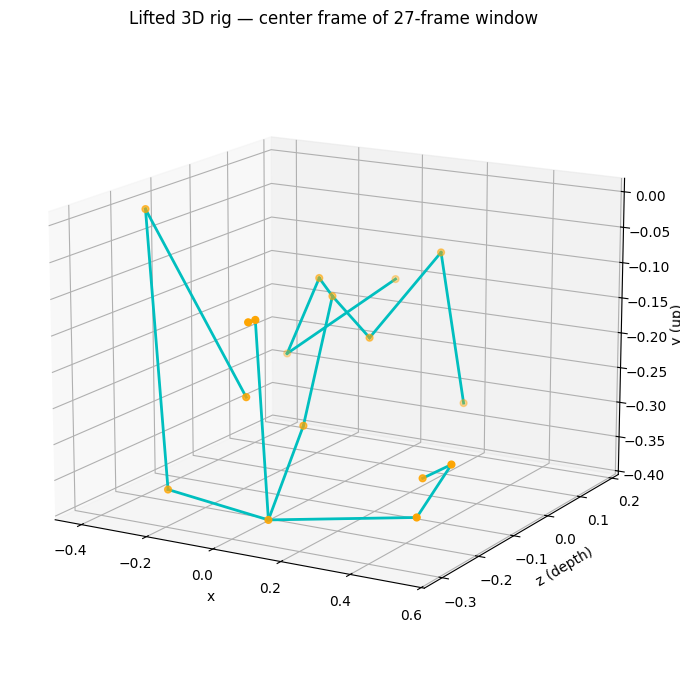

In [7]:
window = np.load(DATA / "squat_window_27.npy")
frame_h, frame_w = (int(v) for v in np.load(DATA / "squat_window_27_shape.npy"))
print("window:", window.shape, "frame:", (frame_h, frame_w))

rig_3d = lifter.infer(window, frame_h=frame_h, frame_w=frame_w)
print("3D rig:", rig_3d.shape)  # (17, 3), Human3.6M-17 layout

# H36M-17 skeleton: pelvis(0), R-leg(1,2,3), L-leg(4,5,6), spine/thorax/neck/head(7,8,9,10),
# L-arm(11,12,13), R-arm(14,15,16). Source: pose3d.COCO_TO_H36M comments.
H36M_SKELETON = [
    (0, 1),
    (1, 2),
    (2, 3),
    (0, 4),
    (4, 5),
    (5, 6),
    (0, 7),
    (7, 8),
    (8, 9),
    (9, 10),
    (8, 11),
    (11, 12),
    (12, 13),
    (8, 14),
    (14, 15),
    (15, 16),
]

xs, ys, zs = rig_3d[:, 0], rig_3d[:, 1], rig_3d[:, 2]
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xs, zs, -ys, c="orange", s=24)
for a, b in H36M_SKELETON:
    ax.plot([xs[a], xs[b]], [zs[a], zs[b]], [-ys[a], -ys[b]], "c-", lw=2)
ax.set_xlabel("x")
ax.set_ylabel("z (depth)")
ax.set_zlabel("y (up)")
ax.set_title("Lifted 3D rig — center frame of 27-frame window")
ax.view_init(elev=15, azim=-60)
plt.tight_layout()
plt.show()

---

**Next:** `02_phases_and_scoring.ipynb` will cover `SquatFSM` + `score_rep` on a recorded clip, and `03_llm.ipynb` will exercise `ThaiCoachLLM` with hand-built `RepAnalysis` objects.
